In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/punicbyte/synthetic-sequences/synthetic_memory_100 (1).csv


# CSV loading + DataLoader + FixedWindowMLP + VanillaRNN

In [2]:
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
csv_files = glob.glob(
    "/kaggle/input/datasets/punicbyte/synthetic-sequences/synthetic_memory_100 (1).csv",
    recursive=True
)

if not csv_files:
    raise FileNotFoundError("Could not find synthetic_memory_100*.csv")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("CSV path:", csv_path)
print(df.head())
print("\nSplit counts:")
print(df["split"].value_counts())

CSV path: /kaggle/input/datasets/punicbyte/synthetic-sequences/synthetic_memory_100 (1).csv
   id  split  sequence_length  \
0   0  train               30   
1   1  train               30   
2   2  train               30   
3   3  train               30   
4   4  train               30   

                                            sequence target_token  label  \
0  START RED dog tree cloud paper BLUE dog BLUE h...          RED      0   
1  START BLUE school tree phone window RED car mu...         BLUE      1   
2  START RED music cloud BLUE BLUE house BLUE gar...          RED      0   
3  START BLUE tree music RED music paper river pa...         BLUE      1   
4  START RED cloud window garden chair cloud BLUE...          RED      0   

  label_name  distractor_count  \
0        RED                 6   
1       BLUE                 4   
2        RED                 6   
3       BLUE                 3   
4        RED                 6   

                                               

In [4]:
df["tokens"] = df["sequence"].astype(str).str.split()

all_tokens = sorted({
    token
    for tokens in df["tokens"]
    for token in tokens
})

id_to_token = ["<PAD>"] + all_tokens
token_to_id = {token: idx for idx, token in enumerate(id_to_token)}
vocab_size = len(id_to_token)
pad_id = token_to_id["<PAD>"]

df["token_ids"] = df["tokens"].apply(
    lambda tokens: [token_to_id[token] for token in tokens]
)

max_length = df["token_ids"].str.len().max()

# Left padding keeps the final QUERY token at the last position.
def left_pad(token_ids):
    return [pad_id] * (max_length - len(token_ids)) + token_ids

train_df = df[df["split"].eq("train")].copy()
val_df = df[df["split"].eq("val")].copy()

X_train = torch.tensor(
    train_df["token_ids"].apply(left_pad).tolist(),
    dtype=torch.long
)
y_train = torch.tensor(train_df["label"].to_numpy(), dtype=torch.long)

X_val = torch.tensor(
    val_df["token_ids"].apply(left_pad).tolist(),
    dtype=torch.long
)
y_val = torch.tensor(val_df["label"].to_numpy(), dtype=torch.long)

print("Vocabulary size:", vocab_size)
print("Train count:", len(X_train))
print("Validation count:", len(X_val))

Vocabulary size: 25
Train count: 80
Validation count: 20


In [5]:
batch_size = 16

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

loader_generator = torch.Generator().manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

batch_X, batch_y = next(iter(train_loader))
print("Batch X shape:", batch_X.shape)
print("Batch y shape:", batch_y.shape)

Batch X shape: torch.Size([16, 30])
Batch y shape: torch.Size([16])


In [6]:
class FixedWindowMLP(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=32,
        window_size=5,
        hidden_size=64,
        num_classes=2,
        padding_idx=0
    ):
        super().__init__()
        self.window_size = window_size
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )
        self.mlp = nn.Sequential(
            nn.Linear(window_size * embedding_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # QUERY is final; select the preceding fixed window.
        window = x[:, -(self.window_size + 1):-1]
        embedded = self.embedding(window)
        flattened = embedded.reshape(embedded.size(0), -1)
        return self.mlp(flattened)

In [7]:
class VanillaRNNFromScratch(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=32,
        hidden_size=64,
        num_classes=2,
        padding_idx=0
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )
        self.input_to_hidden = nn.Linear(
            embedding_dim,
            hidden_size
        )
        self.hidden_to_hidden = nn.Linear(
            hidden_size,
            hidden_size,
            bias=False
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        batch_size, sequence_length, _ = embedded.shape

        hidden_state = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        for timestep in range(sequence_length):
            candidate_state = torch.tanh(
                self.input_to_hidden(embedded[:, timestep, :])
                + self.hidden_to_hidden(hidden_state)
            )

            is_not_padding = (
                x[:, timestep] != self.padding_idx
            ).unsqueeze(1)

            hidden_state = torch.where(
                is_not_padding,
                candidate_state,
                hidden_state
            )

        return self.classifier(hidden_state)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_examples += labels.size(0)

    return total_loss / total_examples


def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    device
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_accuracy": []
    }

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
        val_accuracy = evaluate_accuracy(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val accuracy: {val_accuracy:.4f}"
        )

    return history

In [9]:
fixed_window_model = FixedWindowMLP(
    vocab_size=vocab_size,
    embedding_dim=32,
    window_size=5,
    hidden_size=64,
    num_classes=2,
    padding_idx=pad_id
)

fixed_window_history = train_model(
    fixed_window_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=0.001,
    device=device
)

fixed_window_val_acc = evaluate_accuracy(
    fixed_window_model,
    val_loader,
    device
)

Epoch 01 | Train loss: 0.6717 | Val accuracy: 0.5500
Epoch 02 | Train loss: 0.5804 | Val accuracy: 0.6500
Epoch 03 | Train loss: 0.5131 | Val accuracy: 0.6500
Epoch 04 | Train loss: 0.4460 | Val accuracy: 0.6500
Epoch 05 | Train loss: 0.3806 | Val accuracy: 0.7000
Epoch 06 | Train loss: 0.3210 | Val accuracy: 0.7000
Epoch 07 | Train loss: 0.2660 | Val accuracy: 0.7000
Epoch 08 | Train loss: 0.2175 | Val accuracy: 0.7000
Epoch 09 | Train loss: 0.1755 | Val accuracy: 0.7000
Epoch 10 | Train loss: 0.1396 | Val accuracy: 0.6500
Epoch 11 | Train loss: 0.1125 | Val accuracy: 0.6500
Epoch 12 | Train loss: 0.0910 | Val accuracy: 0.6500
Epoch 13 | Train loss: 0.0745 | Val accuracy: 0.6000
Epoch 14 | Train loss: 0.0609 | Val accuracy: 0.6000
Epoch 15 | Train loss: 0.0506 | Val accuracy: 0.5500
Epoch 16 | Train loss: 0.0421 | Val accuracy: 0.5500
Epoch 17 | Train loss: 0.0358 | Val accuracy: 0.6000
Epoch 18 | Train loss: 0.0308 | Val accuracy: 0.6000
Epoch 19 | Train loss: 0.0267 | Val accuracy: 

In [10]:
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

vanilla_rnn_model = VanillaRNNFromScratch(
    vocab_size=vocab_size,
    embedding_dim=32,
    hidden_size=64,
    num_classes=2,
    padding_idx=pad_id
)

vanilla_rnn_history = train_model(
    vanilla_rnn_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=0.001,
    device=device
)

vanilla_rnn_val_acc = evaluate_accuracy(
    vanilla_rnn_model,
    val_loader,
    device
)

Epoch 01 | Train loss: 0.6805 | Val accuracy: 0.6500
Epoch 02 | Train loss: 0.6423 | Val accuracy: 0.6500
Epoch 03 | Train loss: 0.5893 | Val accuracy: 0.7000
Epoch 04 | Train loss: 0.5317 | Val accuracy: 0.8000
Epoch 05 | Train loss: 0.4624 | Val accuracy: 0.8000
Epoch 06 | Train loss: 0.3665 | Val accuracy: 0.9000
Epoch 07 | Train loss: 0.2506 | Val accuracy: 0.9000
Epoch 08 | Train loss: 0.1795 | Val accuracy: 0.9500
Epoch 09 | Train loss: 0.1399 | Val accuracy: 0.9500
Epoch 10 | Train loss: 0.1239 | Val accuracy: 0.9500
Epoch 11 | Train loss: 0.1075 | Val accuracy: 1.0000
Epoch 12 | Train loss: 0.0893 | Val accuracy: 1.0000
Epoch 13 | Train loss: 0.0796 | Val accuracy: 1.0000
Epoch 14 | Train loss: 0.0555 | Val accuracy: 1.0000
Epoch 15 | Train loss: 0.0423 | Val accuracy: 1.0000
Epoch 16 | Train loss: 0.0349 | Val accuracy: 1.0000
Epoch 17 | Train loss: 0.0222 | Val accuracy: 1.0000
Epoch 18 | Train loss: 0.0174 | Val accuracy: 1.0000
Epoch 19 | Train loss: 0.0144 | Val accuracy: 

In [11]:
print(
    f"FixedWindowMLP final val accuracy: "
    f"{fixed_window_val_acc:.4f}"
)
print(
    f"VanillaRNN final val accuracy: "
    f"{vanilla_rnn_val_acc:.4f}"
)

FixedWindowMLP final val accuracy: 0.6000
VanillaRNN final val accuracy: 1.0000


# LSTM from scratch + comparison

In [12]:
class LSTMFromScratch(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=32,
        hidden_size=64,
        num_classes=2
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        combined_size = embedding_dim + hidden_size
        self.forget_layer = nn.Linear(combined_size, hidden_size)
        self.input_layer = nn.Linear(combined_size, hidden_size)
        self.candidate_layer = nn.Linear(combined_size, hidden_size)
        self.output_layer = nn.Linear(combined_size, hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x, return_gates=False):
        embedded = self.embedding(x)
        batch_size, seq_len, _ = embedded.shape

        hidden_state = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )
        cell_state = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        forget_gate_values = []
        input_gate_values = []
        output_gate_values = []

        for timestep in range(seq_len):
            x_t = embedded[:, timestep, :]
            concat = torch.cat([x_t, hidden_state], dim=1)

            forget_gate = torch.sigmoid(
                self.forget_layer(concat)
            )
            input_gate = torch.sigmoid(
                self.input_layer(concat)
            )
            candidate_cell = torch.tanh(
                self.candidate_layer(concat)
            )
            cell_state = (
                forget_gate * cell_state
                + input_gate * candidate_cell
            )
            output_gate = torch.sigmoid(
                self.output_layer(concat)
            )
            hidden_state = output_gate * torch.tanh(cell_state)

            if return_gates:
                forget_gate_values.append(forget_gate)
                input_gate_values.append(input_gate)
                output_gate_values.append(output_gate)

        logits = self.classifier(hidden_state)

        if not return_gates:
            return logits

        gates = {
            "forget_gates": torch.stack(
                forget_gate_values, dim=1
            ),
            "input_gates": torch.stack(
                input_gate_values, dim=1
            ),
            "output_gates": torch.stack(
                output_gate_values, dim=1
            )
        }
        return logits, gates

In [13]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

lstm_model = LSTMFromScratch(
    vocab_size,
    embedding_dim=32,
    hidden_size=64,
    num_classes=2
).to(device)

lstm_history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=0.001,
    device=device
)

lstm_val_acc = evaluate_accuracy(
    lstm_model,
    val_loader,
    device
)

Epoch 01 | Train loss: 0.6796 | Val accuracy: 0.7500
Epoch 02 | Train loss: 0.6548 | Val accuracy: 0.7500
Epoch 03 | Train loss: 0.6241 | Val accuracy: 0.8500
Epoch 04 | Train loss: 0.5725 | Val accuracy: 0.9000
Epoch 05 | Train loss: 0.4887 | Val accuracy: 0.8500
Epoch 06 | Train loss: 0.3500 | Val accuracy: 0.9500
Epoch 07 | Train loss: 0.2220 | Val accuracy: 0.9500
Epoch 08 | Train loss: 0.1561 | Val accuracy: 0.9500
Epoch 09 | Train loss: 0.1079 | Val accuracy: 0.9500
Epoch 10 | Train loss: 0.0856 | Val accuracy: 0.9500
Epoch 11 | Train loss: 0.0591 | Val accuracy: 0.9500
Epoch 12 | Train loss: 0.0416 | Val accuracy: 0.9500
Epoch 13 | Train loss: 0.0270 | Val accuracy: 0.9500
Epoch 14 | Train loss: 0.0141 | Val accuracy: 0.9500
Epoch 15 | Train loss: 0.0078 | Val accuracy: 0.9500
Epoch 16 | Train loss: 0.0056 | Val accuracy: 0.9500
Epoch 17 | Train loss: 0.0044 | Val accuracy: 0.9500
Epoch 18 | Train loss: 0.0034 | Val accuracy: 0.9500
Epoch 19 | Train loss: 0.0029 | Val accuracy: 

In [14]:
sample_inputs, _ = next(iter(val_loader))

with torch.no_grad():
    sample_logits, sample_gates = lstm_model(
        sample_inputs.to(device),
        return_gates=True
    )

print("Logits shape:", sample_logits.shape)
print(
    "Forget gates shape:",
    sample_gates["forget_gates"].shape
)
print(
    "Input gates shape:",
    sample_gates["input_gates"].shape
)
print(
    "Output gates shape:",
    sample_gates["output_gates"].shape
)

Logits shape: torch.Size([16, 2])
Forget gates shape: torch.Size([16, 30, 64])
Input gates shape: torch.Size([16, 30, 64])
Output gates shape: torch.Size([16, 30, 64])


In [15]:
comparison_df = pd.DataFrame({
    "model": [
        "FixedWindowMLP",
        "VanillaRNNFromScratch",
        "LSTMFromScratch"
    ],
    "validation_accuracy": [
        fixed_window_val_acc,
        vanilla_rnn_val_acc,
        lstm_val_acc
    ]
})

print(comparison_df.to_string(index=False))

                model  validation_accuracy
       FixedWindowMLP                 0.60
VanillaRNNFromScratch                 1.00
      LSTMFromScratch                 0.95


In [16]:
print("RNN uses one hidden state.")
print("LSTM uses hidden_state plus cell_state plus gates.")

RNN uses one hidden state.
LSTM uses hidden_state plus cell_state plus gates.


# plots + inspect predictions + gate values

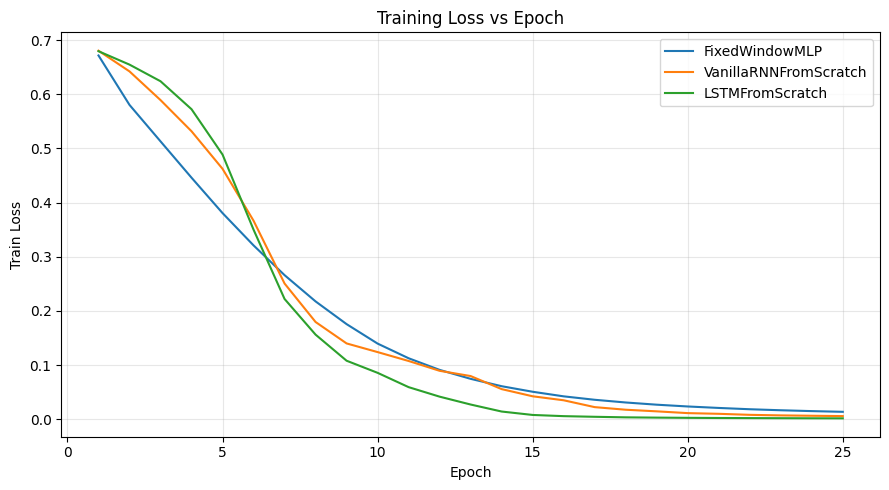

In [17]:
import matplotlib.pyplot as plt

epochs_fixed = range(1, len(fixed_window_history["train_loss"]) + 1)
epochs_rnn = range(1, len(vanilla_rnn_history["train_loss"]) + 1)
epochs_lstm = range(1, len(lstm_history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_fixed,
    fixed_window_history["train_loss"],
    label="FixedWindowMLP"
)
plt.plot(
    epochs_rnn,
    vanilla_rnn_history["train_loss"],
    label="VanillaRNNFromScratch"
)
plt.plot(
    epochs_lstm,
    lstm_history["train_loss"],
    label="LSTMFromScratch"
)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

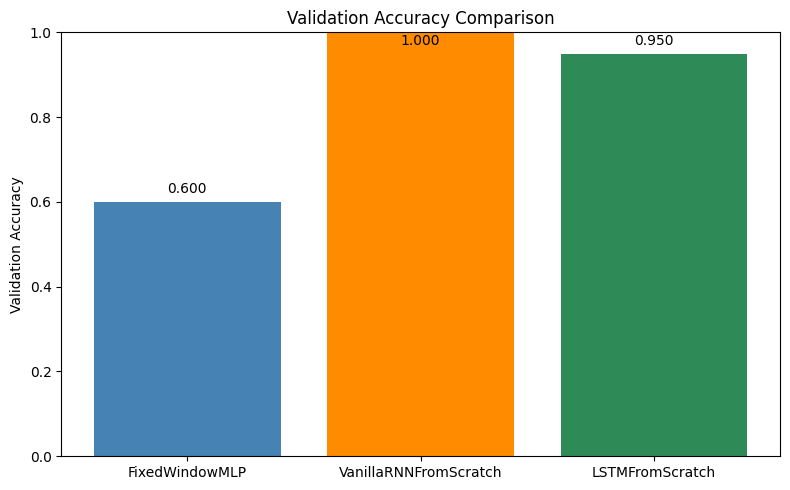

In [18]:
model_names = [
    "FixedWindowMLP",
    "VanillaRNNFromScratch",
    "LSTMFromScratch"
]
validation_accuracies = [
    fixed_window_val_acc,
    vanilla_rnn_val_acc,
    lstm_val_acc
]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    model_names,
    validation_accuracies,
    color=["steelblue", "darkorange", "seagreen"]
)
plt.ylim(0, 1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

for bar, accuracy in zip(bars, validation_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        min(accuracy + 0.02, 0.97),
        f"{accuracy:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [19]:
def inspect_predictions(
    models_dict,
    df,
    token_to_id,
    device,
    num_examples=5
):
    id_to_label = {0: "RED", 1: "BLUE"}
    examples = df[df["split"].eq("val")].head(num_examples)

    for model in models_dict.values():
        model.eval()

    for example_number, (_, row) in enumerate(
        examples.iterrows(),
        start=1
    ):
        tokens = str(row["sequence"]).split()
        token_ids = [token_to_id[token] for token in tokens]
        sequence_tensor = torch.tensor(
            [token_ids],
            dtype=torch.long,
            device=device
        )

        true_label = int(row["label"])
        true_label_name = id_to_label[true_label]

        print(f"\nExample {example_number}")
        print("Sequence:", row["sequence"])
        print("True label_name:", true_label_name)
        print("Distractor count:", row["distractor_count"])

        with torch.no_grad():
            for model_name, model in models_dict.items():
                logits = model(sequence_tensor)
                predicted_id = logits.argmax(dim=1).item()
                predicted_label = id_to_label[predicted_id]
                is_correct = predicted_id == true_label

                print(
                    f"{model_name} prediction: {predicted_label} | "
                    f"Correct: {is_correct}"
                )


models_dict = {
    "FixedWindowMLP": fixed_window_model,
    "VanillaRNNFromScratch": vanilla_rnn_model,
    "LSTMFromScratch": lstm_model
}

inspect_predictions(
    models_dict,
    df,
    token_to_id,
    device,
    num_examples=5
)


Example 1
Sequence: START RED basketball garden river apple paper paper book school river pizza basketball window clock lamp paper lamp apple BLUE chair book pizza car BLUE BLUE book chair garden QUERY
True label_name: RED
Distractor count: 3
FixedWindowMLP prediction: RED | Correct: True
VanillaRNNFromScratch prediction: RED | Correct: True
LSTMFromScratch prediction: RED | Correct: True

Example 2
Sequence: START BLUE RED paper paper apple school chair phone basketball chair RED house garden window paper book book pizza music pizza cloud lamp car RED car RED river RED QUERY
True label_name: BLUE
Distractor count: 5
FixedWindowMLP prediction: BLUE | Correct: True
VanillaRNNFromScratch prediction: BLUE | Correct: True
LSTMFromScratch prediction: BLUE | Correct: True

Example 3
Sequence: START RED house BLUE house school clock music basketball pizza apple BLUE phone BLUE book basketball book house paper dog BLUE tree house tree basketball cloud paper dog window QUERY
True label_name: R

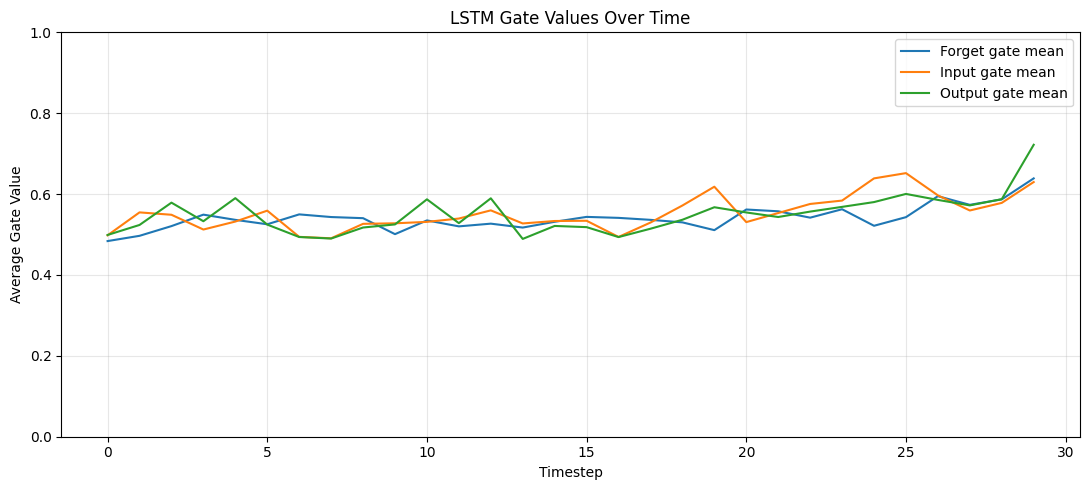

In [20]:
validation_example = df[df["split"].eq("val")].iloc[0]
example_tokens = str(validation_example["sequence"]).split()
example_ids = [token_to_id[token] for token in example_tokens]

example_tensor = torch.tensor(
    [example_ids],
    dtype=torch.long,
    device=device
)

lstm_model.eval()
with torch.no_grad():
    _, gate_values = lstm_model(
        example_tensor,
        return_gates=True
    )

forget_gate_mean = (
    gate_values["forget_gates"]
    .mean(dim=2)
    .squeeze(0)
    .cpu()
    .numpy()
)
input_gate_mean = (
    gate_values["input_gates"]
    .mean(dim=2)
    .squeeze(0)
    .cpu()
    .numpy()
)
output_gate_mean = (
    gate_values["output_gates"]
    .mean(dim=2)
    .squeeze(0)
    .cpu()
    .numpy()
)

timesteps = range(len(example_tokens))

plt.figure(figsize=(11, 5))
plt.plot(timesteps, forget_gate_mean, label="Forget gate mean")
plt.plot(timesteps, input_gate_mean, label="Input gate mean")
plt.plot(timesteps, output_gate_mean, label="Output gate mean")
plt.xlabel("Timestep")
plt.ylabel("Average Gate Value")
plt.title("LSTM Gate Values Over Time")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
print(
    "Dataset tests whether a model can remember the first "
    "RED/BLUE token after START."
)
print("FixedWindowMLP has no real sequence memory.")
print("VanillaRNN has hidden-state memory.")
print("LSTM has gated cell-state memory.")
print("Later RED/BLUE tokens are distractors.")
print("This is why the task demonstrates the purpose of LSTMs.")

Dataset tests whether a model can remember the first RED/BLUE token after START.
FixedWindowMLP has no real sequence memory.
VanillaRNN has hidden-state memory.
LSTM has gated cell-state memory.
Later RED/BLUE tokens are distractors.
This is why the task demonstrates the purpose of LSTMs.
